# 🏙️ Projeto G1 — Mercado Imobiliário Brasileiro (2015–2024)

**Disciplina:** Linguagens de Programação · **Tecnologias:** Python, Pandas, Matplotlib, Seaborn, SQLAlchemy/SQLite e Streamlit

---
## 1. Introdução ao problema

O mercado imobiliário é um dos termômetros mais importantes da economia: o preço dos imóveis influencia o planejamento urbano, o acesso à moradia e as decisões de investimento das famílias. Em teoria, esses preços respondem a fatores como **localização**, **tipo de imóvel**, **renda da população** e **taxa de juros** do financiamento.

Este notebook analisa uma base simulada do mercado imobiliário brasileiro entre 2015 e 2024 para responder às seguintes perguntas:

1. Quais cidades possuem os imóveis mais caros?
2. Houve valorização imobiliária ao longo do tempo?
3. Existem diferenças regionais relevantes?
4. Quais tipos de imóveis possuem maior valor?
5. Existe relação entre renda, juros e preço dos imóveis?
6. Quais cidades apresentaram maior crescimento?
7. Há períodos de aquecimento ou retração do mercado?

Os resultados aqui alimentam o dashboard Streamlit (`app.py`) do projeto.

## 2. Explicação da base de dados

A base `simulacao_mercado_imobiliario_brasil.csv` contém **uma linha por anúncio/transação simulada**, com as colunas abaixo:

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Período da observação (2015-01 a 2024-12) |
| `regiao`, `uf`, `cidade`, `bairro` | Localização do imóvel |
| `tipo_imovel` | Casa, Apartamento, Cobertura, Studio ou Sala Comercial |
| `area_m2`, `quartos`, `vagas_garagem` | Características físicas |
| `preco_imovel` | Preço total do imóvel (R$) |
| `preco_m2` | Preço por metro quadrado (R$) |
| `renda_media` | Renda média local (R$) |
| `taxa_juros` | Taxa de juros do financiamento (% a.a.) |
| `nivel_preco` | Classificação do imóvel: Baixo, Médio, Alto ou Luxo |

> ⚠️ **Atenção:** trata-se de uma base **simulada**. Isso é importante para interpretar os resultados: relações que existem no mundo real (como renda × preço) podem não aparecer aqui.

## 3. Leitura dos dados

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sqlalchemy import create_engine

# Paleta do projeto (verde-azulado + areia, de leitura confortável)
TEAL, TEAL_CLARO, AREIA, OURO = "#14b8a6", "#5eead4", "#d4a373", "#e9c46a"
PALETA = ["#0f766e", "#14b8a6", "#5eead4", "#e9c46a", "#d4a373", "#9ad1b3", "#b08968", "#7fb7a4"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# Caminhos (funciona rodando de dentro de /notebooks ou da raiz do projeto)
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CAMINHO_CSV = RAIZ / "dados" / "simulacao_mercado_imobiliario_brasil.csv"
PASTA_IMG = RAIZ / "imagens"
PASTA_IMG.mkdir(exist_ok=True)

def brl_k(x, _):
    return f"R$ {x/1_000:,.0f} mil".replace(",", ".")

def brl_mi(x, _):
    return f"R$ {x/1_000_000:.1f} mi".replace(".", ",")

df = pd.read_csv(CAMINHO_CSV, encoding="utf-8-sig")
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}".replace(",", "."))
df.head()

Linhas: 4.440 | Colunas: 16


,ano,mes,data,regiao,uf,cidade,bairro,tipo_imovel,area_m2,quartos,vagas_garagem,preco_imovel,preco_m2,renda_media,taxa_juros,nivel_preco
0,2015,1,2015-01-01,Norte,AM,Manaus,Boa Vista,Casa,162,4,3,696835.01,3946.50,2069.62,13.92,Luxo
1,2015,1,2015-01-01,Norte,PA,Belém,Boa Vista,Studio,46,3,2,299378.31,9805.85,2977.65,11.10,Baixo
2,2015,1,2015-01-01,Norte,PA,Santarém,Centro,Cobertura,159,2,1,324224.24,17435.31,4546.93,11.88,Baixo
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Boa Vista,Studio,104,4,2,149498.43,14149.33,4208.43,7.06,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,Boa Vista,Studio,182,0,3,283616.71,9447.97,2753.91,8.64,Baixo


## 4. Limpeza e preparação

Aqui verificamos a qualidade da base: tipos, valores ausentes, duplicatas, coerência entre colunas e valores extremos.

In [2]:
df["data"] = pd.to_datetime(df["data"], errors="coerce")

print("Tipos de dados:")
print(df.dtypes, end="\n\n")
print("Valores nulos por coluna:", int(df.isnull().sum().sum()))
print("Linhas duplicadas:", int(df.duplicated().sum()))
print("Datas inválidas:", int(df["data"].isna().sum()))

Tipos de dados:
ano                       int64
mes                       int64
data             datetime64[us]
regiao                      str
uf                          str
cidade                      str
bairro                      str
tipo_imovel                 str
area_m2                   int64
quartos                   int64
vagas_garagem             int64
preco_imovel            float64
preco_m2                float64
renda_media             float64
taxa_juros              float64
nivel_preco                 str
dtype: object

Valores nulos por coluna: 0
Linhas duplicadas: 0
Datas inválidas: 0


In [3]:
# Coerência: o ano/mês batem com a coluna data?
coerente = ((df["data"].dt.year == df["ano"]) & (df["data"].dt.month == df["mes"])).mean()
print(f"Ano/mês consistentes com 'data': {coerente:.1%}")

# Coerência: preco_m2 é igual a preco_imovel / area_m2?
preco_m2_calc = df["preco_imovel"] / df["area_m2"]
dif = (preco_m2_calc - df["preco_m2"]).abs()
print(f"Diferença média entre preco_m2 informado e calculado: R$ {dif.mean():,.0f}".replace(",", "."))
print(f"Linhas em que preco_m2 bate com preco/area (tolerância R$ 1): {(dif < 1).mean():.1%}")

Ano/mês consistentes com 'data': 100.0%
Diferença média entre preco_m2 informado e calculado: R$ 7.384
Linhas em que preco_m2 bate com preco/area (tolerância R$ 1): 0.0%


**Achado de qualidade:** a coluna `preco_m2` **não é** `preco_imovel ÷ area_m2` — na base simulada ela foi gerada de forma independente. Por isso, neste projeto usamos `preco_imovel` como medida principal de preço e tratamos `preco_m2` como uma variável própria da base, sem recalculá-la. Essa decisão fica documentada para não induzir a erro quem for usar os dados.

In [4]:
# Valores extremos pelo método do IQR (apenas diagnóstico; não removemos)
q1, q3 = df["preco_imovel"].quantile([0.25, 0.75])
limite_sup = q3 + 1.5 * (q3 - q1)
outliers = df[df["preco_imovel"] > limite_sup]
print(f"Limite superior (IQR): R$ {limite_sup:,.0f}".replace(",", "."))
print(f"Imóveis acima do limite: {len(outliers)} ({len(outliers)/len(df):.1%} da base)")

Limite superior (IQR): R$ 1.635.140
Imóveis acima do limite: 248 (5.6% da base)


Os valores altos representam imóveis de alto padrão (coberturas e casas grandes) e são **plausíveis**, então foram **mantidos**. Remover esses casos distorceria justamente o segmento de luxo. Para reduzir a influência deles, usamos também a **mediana** nos KPIs.

**Resumo da limpeza:** a base não tem nulos nem duplicatas, as datas foram convertidas para `datetime` e não foi necessário remover nenhuma linha.

## 5. Engenharia de atributos

Criamos novas colunas para enriquecer a análise: período mensal, faixa de tamanho, faixa de renda e preço por quarto.

In [5]:
df["ano_mes"] = df["data"].dt.to_period("M").astype(str)

df["tamanho_categoria"] = pd.cut(
    df["area_m2"], bins=[0, 60, 120, np.inf],
    labels=["Pequeno (até 60 m²)", "Médio (60–120 m²)", "Grande (> 120 m²)"],
)
df["faixa_renda"] = pd.qcut(df["renda_media"], q=3, labels=["Renda baixa", "Renda média", "Renda alta"])
df["faixa_juros"] = pd.cut(df["taxa_juros"], bins=[0, 9, 12, np.inf], labels=["Juros baixos (até 9%)", "Juros médios (9–12%)", "Juros altos (> 12%)"])
df["preco_por_quarto"] = df["preco_imovel"] / df["quartos"].replace(0, np.nan)

df[["data", "ano_mes", "area_m2", "tamanho_categoria", "renda_media", "faixa_renda", "taxa_juros", "faixa_juros"]].head()

,data,ano_mes,area_m2,tamanho_categoria,renda_media,faixa_renda,taxa_juros,faixa_juros
0,2015-01-01,2015-01,162,Grande (> 120 m²),2069.62,Renda baixa,13.92,Juros altos (> 12%)
1,2015-01-01,2015-01,46,Pequeno (até 60 m²),2977.65,Renda baixa,11.10,Juros médios (9–12%)
2,2015-01-01,2015-01,159,Grande (> 120 m²),4546.93,Renda alta,11.88,Juros médios (9–12%)
3,2015-01-01,2015-01,104,Médio (60–120 m²),4208.43,Renda alta,7.06,Juros baixos (até 9%)
4,2015-01-01,2015-01,182,Grande (> 120 m²),2753.91,Renda baixa,8.64,Juros baixos (até 9%)


### Persistência em banco de dados (SQLite + SQLAlchemy)

Salvamos a base tratada em um banco SQLite para consultas SQL. Usamos uma tabela própria do notebook (`imoveis_notebook`) para não interferir na tabela usada pelo dashboard.

In [6]:
pasta_db = RAIZ / "database"
pasta_db.mkdir(exist_ok=True)
engine = create_engine(f"sqlite:///{pasta_db / 'mercado_imobiliario.sqlite'}")

df_sql = df.copy()
df_sql["data"] = df_sql["data"].dt.strftime("%Y-%m-%d")
for col in ["tamanho_categoria", "faixa_renda", "faixa_juros"]:
    df_sql[col] = df_sql[col].astype(str)
df_sql.to_sql("imoveis_notebook", engine, if_exists="replace", index=False)

print(pd.read_sql("SELECT COUNT(*) AS linhas FROM imoveis_notebook", engine))

   linhas
0    4440


## 6. Análise exploratória de dados (EDA)

### 6.1 Visão geral estatística

In [7]:
colunas_num = ["area_m2", "quartos", "vagas_garagem", "preco_imovel", "preco_m2", "renda_media", "taxa_juros"]
df[colunas_num].describe().round(2)

,area_m2,quartos,vagas_garagem,preco_imovel,preco_m2,renda_media,taxa_juros
count,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00
mean,123.10,1.96,1.49,682299.26,10861.72,3498.05,10.52
std,54.96,1.44,1.12,532001.22,4192.91,706.41,2.04
min,30.00,0.00,0.00,54674.54,3519.52,952.00,7.00
25%,76.00,1.00,0.00,339078.38,7264.42,3012.70,8.73
50%,121.00,2.00,2.00,537645.22,10968.15,3515.40,10.52
75%,171.00,3.00,2.00,857502.97,14479.41,3975.58,12.31
max,219.00,4.00,3.00,6416335.58,17998.70,6341.42,14.00


In [8]:
print("Cidades:", df["cidade"].nunique(), "| UFs:", df["uf"].nunique(), "| Regiões:", df["regiao"].nunique())
print()
print(df["tipo_imovel"].value_counts().to_string())

Cidades: 37 | UFs: 20 | Regiões: 5

tipo_imovel
Cobertura         913
Sala Comercial    904
Casa              896
Studio            890
Apartamento       837


### 6.2 Distribuição do preço dos imóveis

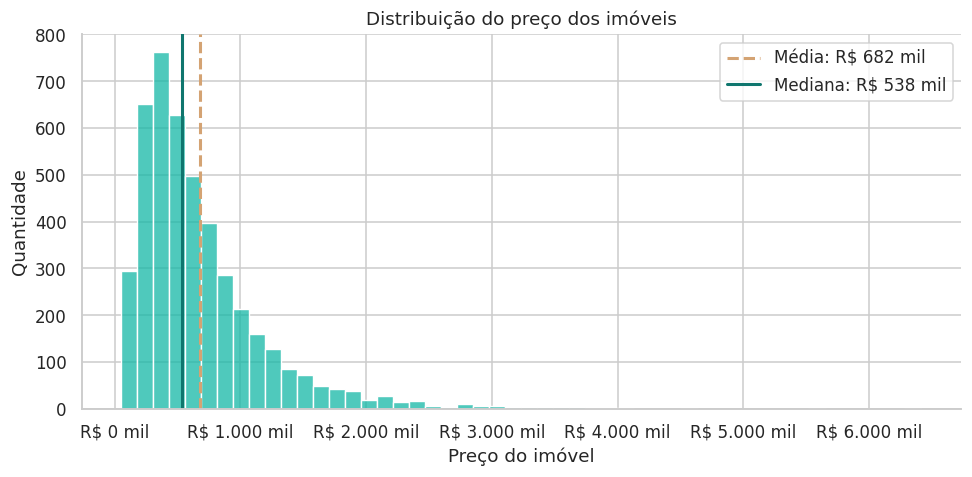

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["preco_imovel"], bins=50, color=TEAL, edgecolor="white", ax=ax)
ax.axvline(df["preco_imovel"].mean(), color=AREIA, linestyle="--", linewidth=2, label=f"Média: {brl_k(df['preco_imovel'].mean(), None)}")
ax.axvline(df["preco_imovel"].median(), color="#0f766e", linestyle="-", linewidth=2, label=f"Mediana: {brl_k(df['preco_imovel'].median(), None)}")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(brl_k))
ax.set_title("Distribuição do preço dos imóveis")
ax.set_xlabel("Preço do imóvel"); ax.set_ylabel("Quantidade")
ax.legend()
plt.tight_layout(); plt.savefig(PASTA_IMG / "distribuicao_preco.png"); plt.show()

**Leitura:** a distribuição é assimétrica à direita — poucos imóveis muito caros puxam a **média** acima da **mediana**. Por isso a mediana é uma medida mais representativa do imóvel "típico".

### 6.3 Evolução temporal dos preços

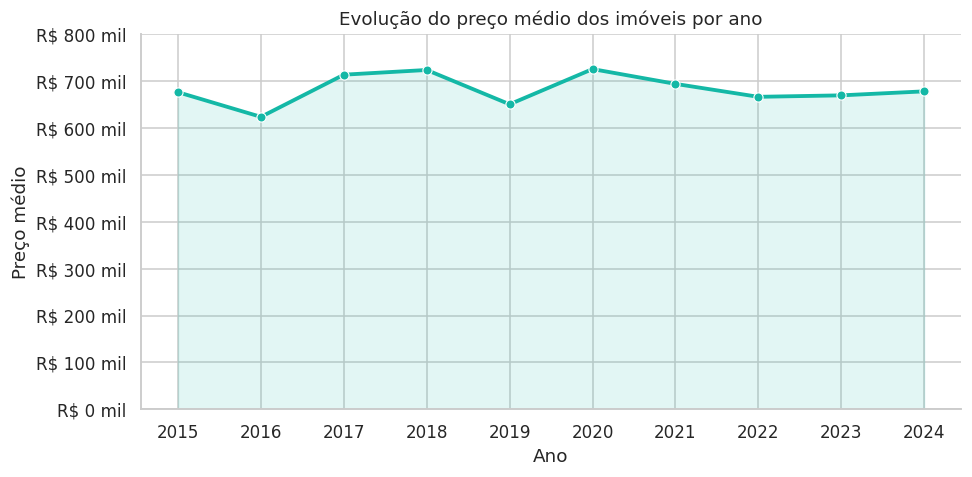

,ano,preco_imovel
0,2015,676377.0
1,2016,623833.0
2,2017,713784.0
3,2018,723843.0
4,2019,650648.0
5,2020,725764.0
6,2021,694202.0
7,2022,666595.0
8,2023,669715.0
9,2024,678232.0


In [10]:
serie_ano = df.groupby("ano")["preco_imovel"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=serie_ano, x="ano", y="preco_imovel", marker="o", linewidth=2.5, color=TEAL, ax=ax)
ax.fill_between(serie_ano["ano"], serie_ano["preco_imovel"], alpha=0.12, color=TEAL)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(brl_k))
ax.set_xticks(serie_ano["ano"])
ax.set_ylim(0, 800_000)
ax.set_title("Evolução do preço médio dos imóveis por ano")
ax.set_xlabel("Ano"); ax.set_ylabel("Preço médio")
plt.tight_layout(); plt.savefig(PASTA_IMG / "evolucao_anual.png"); plt.show()

serie_ano.assign(preco_imovel=serie_ano["preco_imovel"].round(0))

### 6.4 Comparação regional

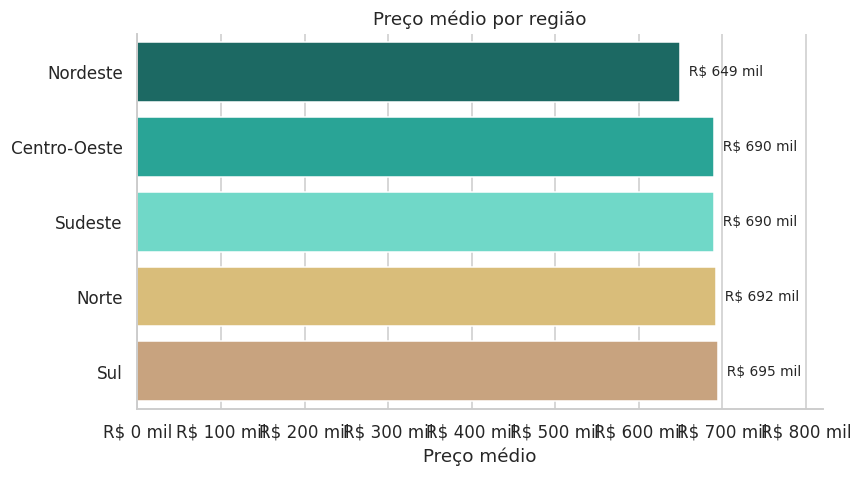

Diferença entre a região mais cara (Sul) e a mais barata (Nordeste): 7.1%


In [11]:
preco_regiao = df.groupby("regiao")["preco_imovel"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=preco_regiao.values, y=preco_regiao.index, hue=preco_regiao.index, palette=PALETA[:5], legend=False, dodge=False, ax=ax)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(brl_k))
ax.set_title("Preço médio por região")
ax.set_xlabel("Preço médio"); ax.set_ylabel("")
for i, v in enumerate(preco_regiao.values):
    ax.text(v, i, f"  {brl_k(v, None)}", va="center", fontsize=9)
ax.set_xlim(0, preco_regiao.max() * 1.18)
plt.tight_layout(); plt.savefig(PASTA_IMG / "preco_regiao.png"); plt.show()

dif_reg = (preco_regiao.max() / preco_regiao.min() - 1) * 100
print(f"Diferença entre a região mais cara ({preco_regiao.idxmax()}) e a mais barata ({preco_regiao.idxmin()}): {dif_reg:.1f}%")

### 6.5 Tipo de imóvel e nível de preço

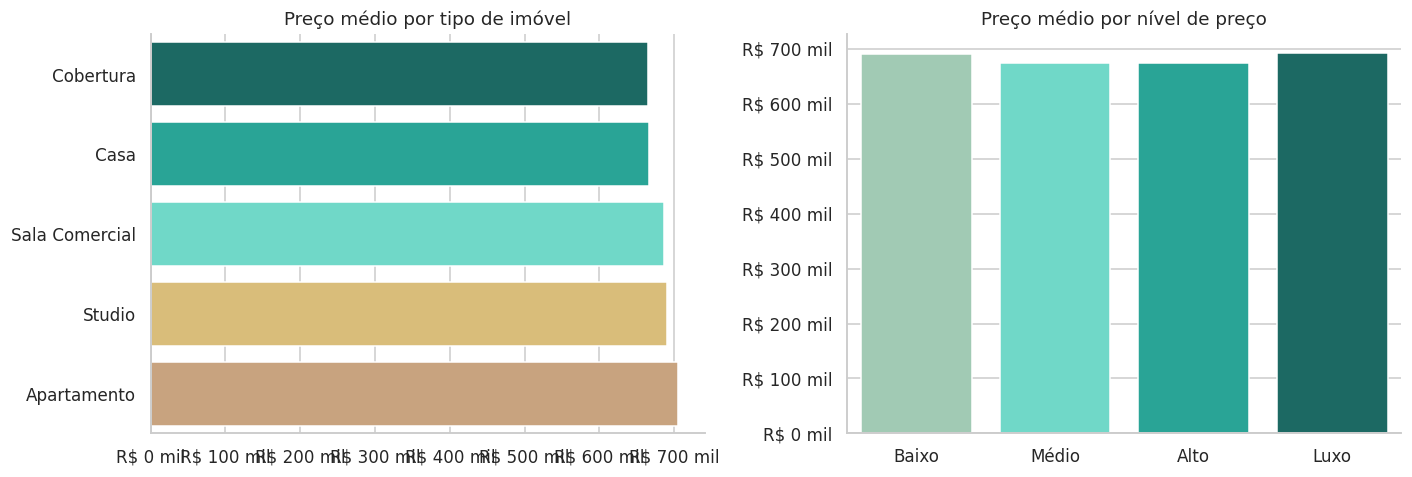

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

preco_tipo = df.groupby("tipo_imovel")["preco_imovel"].mean().sort_values()
sns.barplot(x=preco_tipo.values, y=preco_tipo.index, hue=preco_tipo.index, palette=PALETA[:5], legend=False, dodge=False, ax=axes[0])
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(brl_k))
axes[0].set_title("Preço médio por tipo de imóvel"); axes[0].set_xlabel(""); axes[0].set_ylabel("")

ordem = ["Baixo", "Médio", "Alto", "Luxo"]
preco_nivel = df.groupby("nivel_preco")["preco_imovel"].mean().reindex(ordem)
sns.barplot(x=preco_nivel.index, y=preco_nivel.values, hue=preco_nivel.index, palette=["#9ad1b3", "#5eead4", "#14b8a6", "#0f766e"], legend=False, dodge=False, ax=axes[1])
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(brl_k))
axes[1].set_title("Preço médio por nível de preço"); axes[1].set_xlabel(""); axes[1].set_ylabel("")

plt.tight_layout(); plt.savefig(PASTA_IMG / "preco_tipo_nivel.png"); plt.show()

**Observação importante:** o `nivel_preco` (Baixo → Luxo) **não acompanha o preço real em reais** — a média de "Baixo" é praticamente igual à de "Luxo". Ou seja, na base simulada esse rótulo foi atribuído de forma independente do valor do imóvel, e deve ser tratado como uma categoria à parte, não como faixa de preço.

### 6.6 Cidades mais caras e maior crescimento

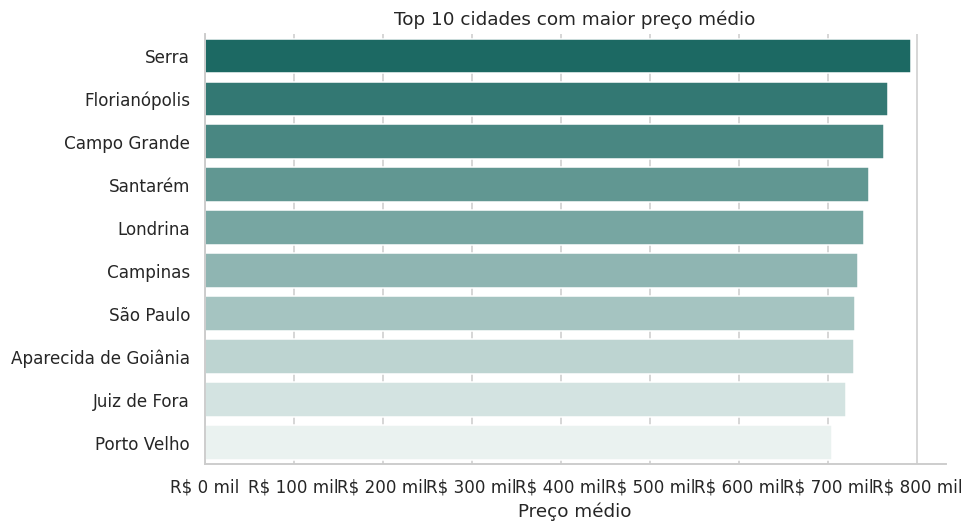

In [13]:
top_cidades = df.groupby("cidade")["preco_imovel"].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_cidades.values, y=top_cidades.index, hue=top_cidades.index, palette=sns.light_palette("#0f766e", n_colors=10, reverse=True), legend=False, dodge=False, ax=ax)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(brl_k))
ax.set_title("Top 10 cidades com maior preço médio")
ax.set_xlabel("Preço médio"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(PASTA_IMG / "top_cidades.png"); plt.show()

In [14]:
# Crescimento médio anual (CAGR) por cidade: 2015 -> 2024
por_cidade_ano = df.groupby(["cidade", "ano"])["preco_imovel"].mean().unstack()
cagr_cidade = (((por_cidade_ano[2024] / por_cidade_ano[2015]) ** (1 / 9) - 1) * 100).dropna().sort_values(ascending=False)

print("Maiores crescimentos (% a.a.):")
print(cagr_cidade.head(5).round(1).to_string())
print("\nMaiores quedas (% a.a.):")
print(cagr_cidade.tail(5).round(1).to_string())

Maiores crescimentos (% a.a.):
cidade
Fortaleza         7.8
Salvador          6.6
Belo Horizonte    6.6
Rio de Janeiro    4.6
Campinas          3.4

Maiores quedas (% a.a.):
cidade
Cuiabá                  -3.7
Aparecida de Goiânia    -5.9
Vila Velha              -6.3
Curitiba                -7.0
Petrópolis             -10.1


> As médias por cidade e ano se baseiam em poucas observações, então o CAGR por cidade é **sensível a ruído**: ele indica quais cidades mudaram mais nesta amostra, mas não deve ser lido como tendência firme de mercado.

### 6.7 Sazonalidade (aquecimento e retração)

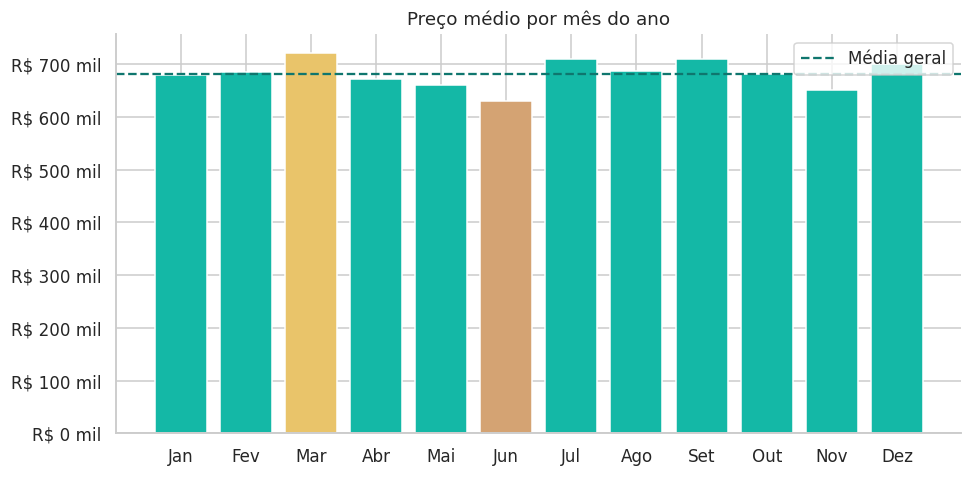

Mês mais alto: Mar | Mês mais baixo: Jun


In [15]:
sazonal = df.groupby("mes")["preco_imovel"].mean()
nomes_mes = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

fig, ax = plt.subplots(figsize=(9, 4.5))
cores = [OURO if v == sazonal.max() else (AREIA if v == sazonal.min() else TEAL) for v in sazonal.values]
ax.bar(nomes_mes, sazonal.values, color=cores)
ax.axhline(df["preco_imovel"].mean(), color="#0f766e", linestyle="--", linewidth=1.5, label="Média geral")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(brl_k))
ax.set_title("Preço médio por mês do ano")
ax.legend()
plt.tight_layout(); plt.savefig(PASTA_IMG / "sazonalidade.png"); plt.show()

print(f"Mês mais alto: {nomes_mes[sazonal.idxmax()-1]} | Mês mais baixo: {nomes_mes[sazonal.idxmin()-1]}")

### 6.8 Correlação estatística

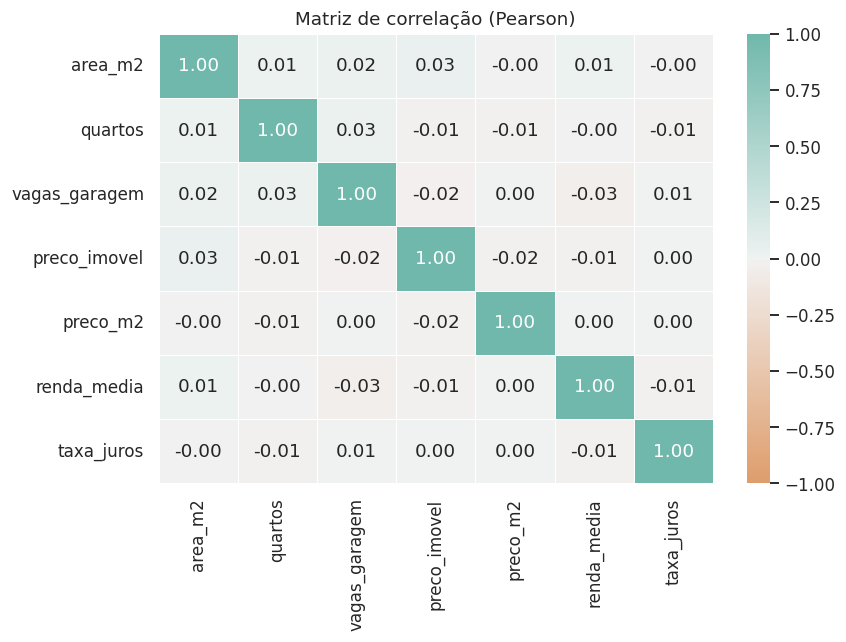

Correlação com o preço do imóvel:
area_m2          0.032
quartos         -0.012
vagas_garagem   -0.020
preco_m2        -0.015
renda_media     -0.011
taxa_juros       0.002


In [16]:
corr = df[colunas_num].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.diverging_palette(40, 175, s=60, l=70, as_cmap=True),
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
plt.tight_layout(); plt.savefig(PASTA_IMG / "heatmap_correlacao.png"); plt.show()

print("Correlação com o preço do imóvel:")
print(corr["preco_imovel"].drop("preco_imovel").round(3).to_string())

In [17]:
# Preço médio por faixa de renda e de juros (confirma visualmente a correlação)
print(df.groupby("faixa_renda", observed=True)["preco_imovel"].mean().round(0).to_string())
print()
print(df.groupby("faixa_juros", observed=True)["preco_imovel"].mean().round(0).to_string())

faixa_renda
Renda baixa    693715.0
Renda média    681347.0
Renda alta     671836.0

faixa_juros
Juros baixos (até 9%)    676641.0
Juros médios (9–12%)     685979.0
Juros altos (> 12%)      682504.0


## 7. KPIs

In [18]:
preco_medio   = df["preco_imovel"].mean()
preco_mediano = df["preco_imovel"].median()
preco_m2_med  = df["preco_m2"].mean()
juros_medio   = df["taxa_juros"].mean()
renda_media   = df["renda_media"].mean()
area_media    = df["area_m2"].mean()
cagr_nacional = ((serie_ano["preco_imovel"].iloc[-1] / serie_ano["preco_imovel"].iloc[0]) ** (1 / 9) - 1) * 100
cidade_cara   = df.groupby("cidade")["preco_imovel"].mean().idxmax()
regiao_cara   = df.groupby("regiao")["preco_imovel"].mean().idxmax()

fmt = lambda v: f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
kpis = pd.DataFrame({
    "KPI": ["Preço médio", "Preço mediano", "Preço médio do m²", "Taxa de juros média", "Renda média",
            "Área média", "Crescimento médio anual (CAGR)", "Cidade mais cara", "Região mais cara"],
    "Valor": [fmt(preco_medio), fmt(preco_mediano), fmt(preco_m2_med), f"{juros_medio:.2f}%", fmt(renda_media),
              f"{area_media:.0f} m²", f"{cagr_nacional:.2f}% a.a.", cidade_cara, regiao_cara],
})
kpis

,KPI,Valor
0,Preço médio,"R$ 682.299,26"
1,Preço mediano,"R$ 537.645,22"
2,Preço médio do m²,"R$ 10.861,72"
3,Taxa de juros média,10.52%
4,Renda média,"R$ 3.498,05"
5,Área média,123 m²
6,Crescimento médio anual (CAGR),0.03% a.a.
7,Cidade mais cara,Serra
8,Região mais cara,Sul


### KPIs via consulta SQL

In [19]:
consulta = """
SELECT regiao,
       COUNT(*)                     AS imoveis,
       ROUND(AVG(preco_imovel), 0)  AS preco_medio,
       ROUND(AVG(preco_m2), 0)      AS preco_m2_medio,
       ROUND(AVG(taxa_juros), 2)    AS juros_medio
FROM imoveis_notebook
GROUP BY regiao
ORDER BY preco_medio DESC
"""
pd.read_sql(consulta, engine)

,regiao,imoveis,preco_medio,preco_m2_medio,juros_medio
0,Sul,720,695080.0,10787.0,10.48
1,Norte,600,691902.0,10767.0,10.50
2,Sudeste,1560,690183.0,10942.0,10.47
3,Centro-Oeste,600,689972.0,10932.0,10.61
4,Nordeste,960,649106.0,10802.0,10.60


## 8. Gráficos

Os gráficos principais foram construídos nas seções 6.2 a 6.8 e salvos automaticamente na pasta `imagens/`. Abaixo, uma visão geral comparando os principais cortes da base em um único painel.

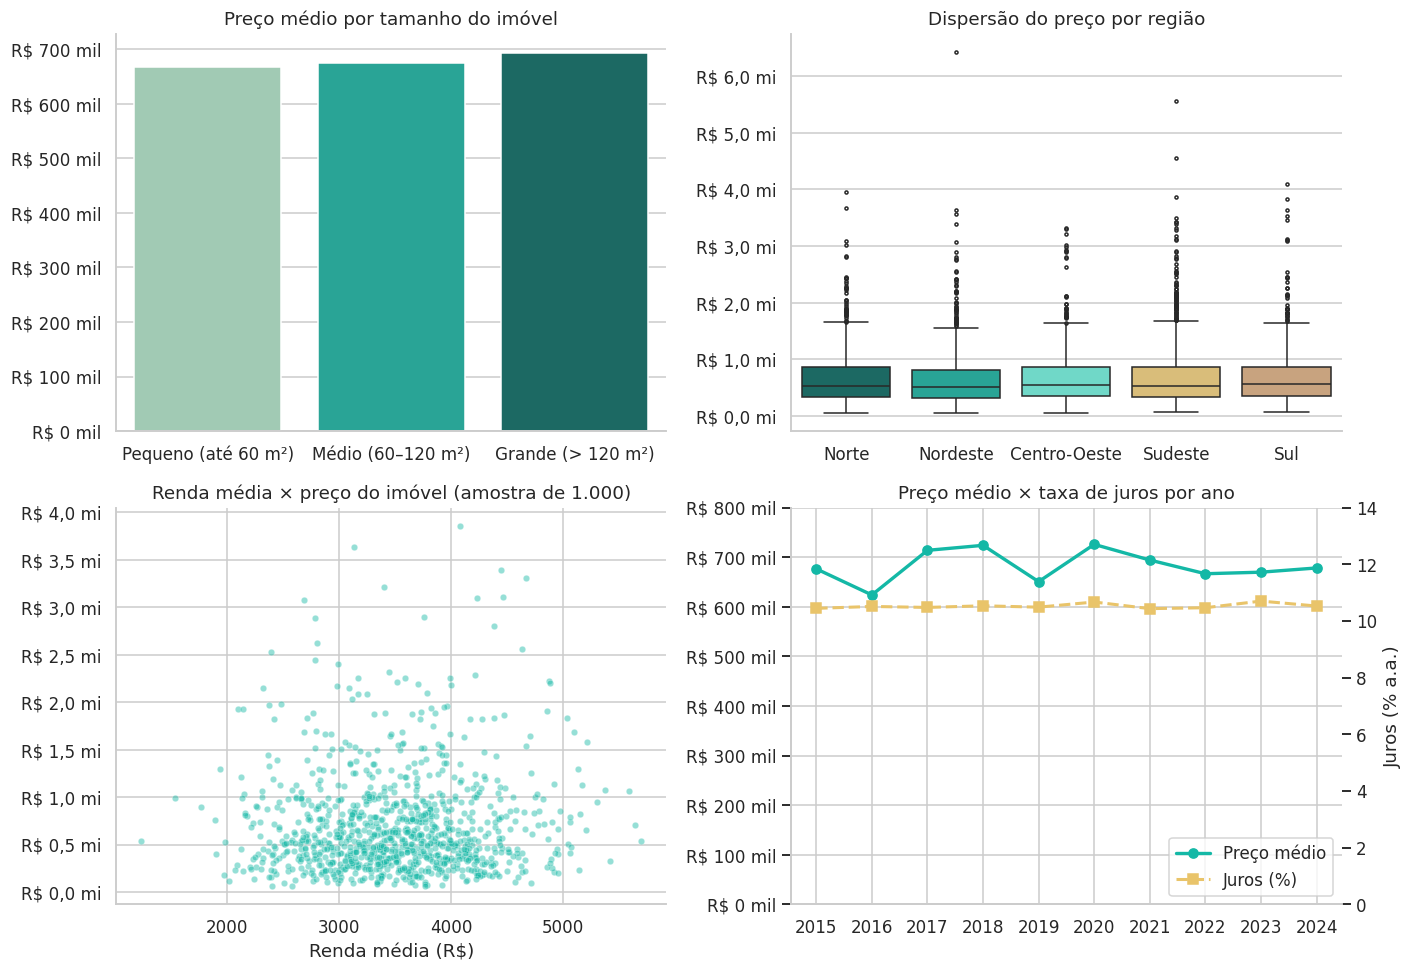

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Preço por tamanho
tam = df.groupby("tamanho_categoria", observed=True)["preco_imovel"].mean()
sns.barplot(x=tam.index, y=tam.values, hue=tam.index, palette=["#9ad1b3", "#14b8a6", "#0f766e"], legend=False, dodge=False, ax=axes[0, 0])
axes[0, 0].set_title("Preço médio por tamanho do imóvel"); axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("")
axes[0, 0].yaxis.set_major_formatter(mtick.FuncFormatter(brl_k))

# 2. Boxplot por região
sns.boxplot(data=df, x="regiao", y="preco_imovel", hue="regiao", palette=PALETA[:5], legend=False, fliersize=2, ax=axes[0, 1])
axes[0, 1].set_title("Dispersão do preço por região"); axes[0, 1].set_xlabel(""); axes[0, 1].set_ylabel("")
axes[0, 1].yaxis.set_major_formatter(mtick.FuncFormatter(brl_mi))

# 3. Renda x preço (amostra)
amostra = df.sample(1000, random_state=42)
sns.scatterplot(data=amostra, x="renda_media", y="preco_imovel", color=TEAL, alpha=0.45, s=18, ax=axes[1, 0])
axes[1, 0].set_title("Renda média × preço do imóvel (amostra de 1.000)")
axes[1, 0].set_xlabel("Renda média (R$)"); axes[1, 0].set_ylabel("")
axes[1, 0].yaxis.set_major_formatter(mtick.FuncFormatter(brl_mi))

# 4. Juros x preço por ano
jp = df.groupby("ano").agg(preco=("preco_imovel", "mean"), juros=("taxa_juros", "mean")).reset_index()
axes[1, 1].plot(jp["ano"], jp["preco"], color=TEAL, marker="o", linewidth=2.2, label="Preço médio")
axes[1, 1].yaxis.set_major_formatter(mtick.FuncFormatter(brl_k))
ax2 = axes[1, 1].twinx()
ax2.plot(jp["ano"], jp["juros"], color=OURO, marker="s", linestyle="--", linewidth=2, label="Juros (%)")
ax2.grid(False)
ax2.set_ylim(0, 14); ax2.set_ylabel("Juros (% a.a.)")
axes[1, 1].set_ylim(0, 800_000)
axes[1, 1].set_title("Preço médio × taxa de juros por ano")
axes[1, 1].set_xticks(jp["ano"])
h1, l1 = axes[1, 1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
axes[1, 1].legend(h1 + h2, l1 + l2, loc="lower right")

plt.tight_layout(); plt.savefig(PASTA_IMG / "painel_geral.png"); plt.show()

## 9. Interpretação dos resultados

Respondendo às perguntas do problema com base nos dados:

**1. Quais cidades possuem imóveis mais caros?** Serra lidera o preço médio (cerca de R$ 793 mil), seguida de Florianópolis, Campo Grande, Santarém e Londrina. A cidade mais barata, Juazeiro do Norte, fica perto de R$ 603 mil. A diferença existe, mas não é enorme.

**2. Houve valorização imobiliária ao longo do tempo?** Praticamente não. O preço médio nacional foi de ~R$ 676 mil em 2015 para ~R$ 678 mil em 2024, um crescimento médio de apenas **0,03% ao ano**. A série oscila (mínimo em 2016, máximo em 2020), mas sem tendência clara de alta.

**3. Existem diferenças regionais relevantes?** Existem, mas são moderadas: o **Sul** tem o maior preço médio e o **Nordeste** o menor, com diferença de cerca de 7%. As demais regiões ficam muito próximas.

**4. Quais tipos de imóveis possuem maior valor?** **Apartamentos** têm a maior média, e **coberturas** a menor — algo contraintuitivo no mundo real, mas que reflete a natureza simulada da base. As diferenças entre tipos são pequenas.

**5. Existe relação entre renda, juros e preço?** Não. As correlações do preço com renda, juros e área estão todas **próximas de zero** (entre −0,02 e +0,03). No mundo real esperaríamos relação negativa com juros e positiva com renda; aqui os dados não mostram isso.

**6. Quais cidades apresentaram maior crescimento?** Fortaleza (~7,8% a.a.), Salvador e Belo Horizonte (~6,6% a.a.) lideram, mas, como são médias de poucas observações, esse resultado deve ser lido com cautela.

**7. Há períodos de aquecimento ou retração?** Sim, pontualmente: 2016 e 2019 foram anos de preços mais baixos e 2017–2018 e 2020 de preços mais altos. Por mês, o pico é em março e o vale em junho, mas a variação não forma um padrão sazonal consistente.

## 10. Conclusão

A análise mostra que, nesta base simulada, o mercado imobiliário brasileiro de 2015 a 2024 teve **preços estáveis**: o preço médio ficou em torno de **R$ 682 mil** (mediana de ~R$ 538 mil), sem valorização acumulada relevante no período. As diferenças entre regiões, tipos de imóvel e cidades existem, mas são **pequenas**, e as variáveis econômicas (renda e juros) **não explicam** o preço.

Esse último ponto é, em si, um achado: ele indica que a base foi gerada sem relações causais entre as variáveis. Além disso, encontramos duas inconsistências que merecem cuidado — `preco_m2` não equivale a `preco_imovel ÷ area_m2` e `nivel_preco` não acompanha o valor em reais.

**Limitações:** dados simulados; poucas observações por cidade/ano; ausência de variáveis como inflação, oferta e financiamento que explicariam preços reais.

**Próximos passos:** testar a mesma metodologia com dados reais (por exemplo, índice FipeZAP ou dados do Banco Central), e incluir modelos de regressão para medir o efeito conjunto de renda, juros e localização.

O dashboard interativo em Streamlit (`app.py`) aplica estes mesmos indicadores com filtros dinâmicos para exploração.